# ВЫВОДЫ В КОНЦЕ ТЕТРАДКИ

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path.cwd().parent
FILENAME = "telco-customer-churn.csv"

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(Path(PROJECT_DIR, "data", "raw", FILENAME))

In [3]:
df.shape

(20468, 29)

In [4]:
df.head(20)

,age,annualincome,calldroprate,callfailurerate,callingnum,customerid,customersuspended,education,gender,homeowner,maritalstatus,monthlybilledamount,noadditionallines,numberofcomplaints,numberofmonthunpaid,numdayscontractequipmentplanexpiring,occupation,penaltytoswitch,state,totalminsusedinlastmonth,unpaidbalance,usesinternetservice,usesvoiceservice,percentagecalloutsidenetwork,totalcallduration,avgcallduration,churn,year,month
0,12,168147,0.06,0.00,4251078442,1,Yes,Bachelor or equivalent,Male,Yes,Single,71,\N,0,7,96,Technology Related Job,371,WA,15,19,No,No,0.82,5971,663,0,2015,1
1,12,168147,0.06,0.00,4251078442,1,Yes,Bachelor or equivalent,Male,Yes,Single,71,\N,0,7,96,Technology Related Job,371,WA,15,19,No,No,0.82,3981,995,0,2015,2
2,42,29047,0.05,0.01,4251043419,2,Yes,Bachelor or equivalent,Female,Yes,Single,8,\N,1,4,14,Technology Related Job,43,WI,212,34,No,Yes,0.27,7379,737,0,2015,1
3,42,29047,0.05,0.01,4251043419,2,Yes,Bachelor or equivalent,Female,Yes,Single,8,\N,1,4,14,Technology Related Job,43,WI,212,34,No,Yes,0.27,1729,432,0,2015,2
4,58,27076,0.07,0.02,4251055773,3,Yes,Master or equivalent,Female,Yes,Single,16,\N,0,2,55,Technology Related Job,403,KS,216,144,No,No,0.48,3122,624,0,2015,1
5,58,27076,0.07,0.02,4251055773,3,Yes,Master or equivalent,Female,Yes,Single,16,\N,0,2,55,Technology Related Job,403,KS,216,144,No,No,0.48,2769,553,0,2015,2
6,20,137977,0.05,0.03,4251042488,4,Yes,PhD or equivalent,Male,No,Single,74,\N,1,7,73,Technology Related Job,76,KY,412,159,Yes,No,0.94,834,834,0,2015,1
7,20,137977,0.05,0.03,4251042488,4,Yes,PhD or equivalent,Male,No,Single,74,\N,1,7,73,Technology Related Job,76,KY,412,159,Yes,No,0.94,5868,838,0,2015,2
8,36,136006,0.07,0.00,4251073177,5,Yes,High School or below,Male,Yes,Married,81,\N,0,5,14,Technology Related Job,436,ND,416,19,No,No,0.15,1886,628,0,2015,1
9,36,136006,0.07,0.00,4251073177,5,Yes,High School or below,Male,Yes,Married,81,\N,0,5,14,Technology Related Job,436,ND,416,19,No,No,0.15,2602,867,0,2015,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20468 entries, 0 to 20467
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   20468 non-null  int64  
 1   annualincome                          20468 non-null  int64  
 2   calldroprate                          20468 non-null  float64
 3   callfailurerate                       20468 non-null  float64
 4   callingnum                            20468 non-null  int64  
 5   customerid                            20468 non-null  int64  
 6   customersuspended                     20468 non-null  str    
 7   education                             20468 non-null  str    
 8   gender                                20468 non-null  str    
 9   homeowner                             20468 non-null  str    
 10  maritalstatus                         20468 non-null  str    
 11  monthlybilledamount       

In [6]:
# Количество уникальных клиентов
print(f"Количество уникальных клиентов: {df["customerid"].nunique()}")
print(f"Среднее количество записей на клиента: {df.shape[0] / df["customerid"].nunique():.2f}")

Количество уникальных клиентов: 9525
Среднее количество записей на клиента: 2.15


Все клиенты имеют одинаковую метку churn во всех своих записях


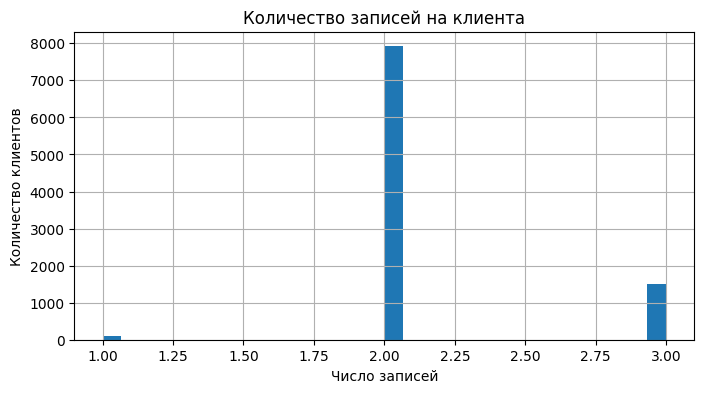

In [7]:
# Проверка, есть ли клиенты с разными значениями churn
churn_per_customer = df.groupby('customerid')['churn'].nunique()
mixed = churn_per_customer[churn_per_customer > 1].index
if len(mixed) > 0:
    print(f"Найдено {len(mixed)} клиентов с противоречивыми метками churn")
else:
    print("Все клиенты имеют одинаковую метку churn во всех своих записях")

# Распределение количества записей на клиента
records_per_customer = df.groupby('customerid').size()
plt.figure(figsize=(8,4))
records_per_customer.hist(bins=30)
plt.title('Количество записей на клиента')
plt.xlabel('Число записей')
plt.ylabel('Количество клиентов')
plt.show()

Поскольку для одного и того же `customerid` мы видим несколько строк с одинаковым значением `churn` (либо все 0, либо все 1), это означает, что `churn` — это статическая метка, которая показывает, ушёл ли клиент когда-либо за весь период наблюдения. То есть если клиент ушёл, то во всех его записях `churn = 1`, если нет — `churn = 0`. Сами записи — это помесячные наблюдения за поведением клиента (повторяющиеся данные по месяцам).

Такая структура данных не подходит для прямого построения модели на уровне строк, поэтому необходимо агрегировать данные на уровне клиента, чтобы у нас была одна строка на `customerid` с агрегированными признаками. После агрегации можно строить модель бинарной классификации.

In [8]:
# Проверка, есть ли клиенты с разными значениями callingnum (как я понял, это номер телефона)
telephone_per_customer = df.groupby('customerid')['callingnum'].nunique()
mixed = telephone_per_customer[telephone_per_customer > 1].index
if len(mixed) > 0:
    print(f"Найдено {len(mixed)} клиентов с несколькими номерами телефонов")
else:
    print("Все клиенты имеют по одному номеру телефона")

Все клиенты имеют по одному номеру телефона


In [9]:
df.noadditionallines.value_counts()

noadditionallines
\N    20468
Name: count, dtype: int64

Столбец `noadditionallines` также подтверждает эту информацию, поэтому можно исключить их из признаков за ненадобностью

In [10]:
# Нужно выяснить, какие признаки статичны, а какие нужно будет агрегировать

def check_static_feature(df: pd.DataFrame, col: str, customer_id_col: str='customerid'):
    """
    Проверяет, является ли категориальный признак статичным.
    Возвращает:
        - is_static: bool, True если все клиенты имеют только одно значение
        - clients_with_changes: список customerid, у которых признак менялся
    """
    # Группируем по клиенту и смотрим количество уникальных значений
    unique_counts = df.groupby(customer_id_col)[col].nunique()
    clients_with_changes = unique_counts[unique_counts > 1].index.tolist()
    is_static = len(clients_with_changes) == 0
    return is_static, clients_with_changes

for col in df.columns:
    is_static, changed = check_static_feature(df, col)
    if not is_static:
        print(f"❌ {col}: не статичен, меняется у {len(changed)} клиентов")
        print(f"   Примеры: {changed[:5]}")
    else:
        print(f"✅ {col}: статичен")

✅ age: статичен
✅ annualincome: статичен
✅ calldroprate: статичен
✅ callfailurerate: статичен
✅ callingnum: статичен
✅ customerid: статичен
✅ customersuspended: статичен
✅ education: статичен
✅ gender: статичен
✅ homeowner: статичен
✅ maritalstatus: статичен
✅ monthlybilledamount: статичен
✅ noadditionallines: статичен
✅ numberofcomplaints: статичен
✅ numberofmonthunpaid: статичен
✅ numdayscontractequipmentplanexpiring: статичен
✅ occupation: статичен
✅ penaltytoswitch: статичен
✅ state: статичен
✅ totalminsusedinlastmonth: статичен
✅ unpaidbalance: статичен
✅ usesinternetservice: статичен
✅ usesvoiceservice: статичен
✅ percentagecalloutsidenetwork: статичен
❌ totalcallduration: не статичен, меняется у 9427 клиентов
   Примеры: [1, 2, 3, 4, 5]
❌ avgcallduration: не статичен, меняется у 9414 клиентов
   Примеры: [1, 2, 3, 4, 5]
✅ churn: статичен
✅ year: статичен
❌ month: не статичен, меняется у 9430 клиентов
   Примеры: [1, 2, 3, 4, 5]


In [11]:
# Определю статичные и динамические признаки, а также укажу их в удобном для себя порядке
static_cols = [
    "age",
    "gender",
    "maritalstatus",
    "education",
    "occupation",
    "annualincome",
    "homeowner",
    "state",
    "monthlybilledamount",
    "totalminsusedinlastmonth",
    "unpaidbalance",
    "numberofmonthunpaid",
    "numberofcomplaints",
    "numdayscontractequipmentplanexpiring",
    "customersuspended",
    "penaltytoswitch",
    "calldroprate",
    "callfailurerate",
    "usesinternetservice",
    "usesvoiceservice",
    "percentagecalloutsidenetwork"
]

dynamic_num_cols = ["totalcallduration", "avgcallduration"]

# Создаём агрегированный DataFrame
agg_dict = {col: 'first' for col in static_cols}
for col in dynamic_num_cols:
    agg_dict[col] = ['mean', 'std', 'min', 'max']
agg_dict['churn'] = 'max'

df_agg = df.groupby('customerid').agg(agg_dict)

# Разворачиваем мультииндекс в плоские имена столбцов
df_agg.columns = ['_'.join(col).strip('_')  if col[1] != "first" else col[0] for col in df_agg.columns.values]
df_agg.reset_index(inplace=True)

# Удаляем customerid (не нужен как признак)
df_agg.drop(columns=['customerid'], inplace=True)

print(f"Размер после агрегации: {df_agg.shape}")
df_agg.head()

Размер после агрегации: (9525, 30)


,age,gender,maritalstatus,education,occupation,annualincome,homeowner,state,monthlybilledamount,totalminsusedinlastmonth,unpaidbalance,numberofmonthunpaid,numberofcomplaints,numdayscontractequipmentplanexpiring,customersuspended,penaltytoswitch,calldroprate,callfailurerate,usesinternetservice,usesvoiceservice,percentagecalloutsidenetwork,totalcallduration_mean,totalcallduration_std,totalcallduration_min,totalcallduration_max,avgcallduration_mean,avgcallduration_std,avgcallduration_min,avgcallduration_max,churn_max
0,12,Male,Single,Bachelor or equivalent,Technology Related Job,168147,Yes,WA,71,15,19,7,0,96,Yes,371,0.06,0.00,No,No,0.82,4976.0,1407.142495,3981,5971,829.0,234.759451,663,995,0
1,42,Female,Single,Bachelor or equivalent,Technology Related Job,29047,Yes,WI,8,212,34,4,1,14,Yes,43,0.05,0.01,No,Yes,0.27,4554.0,3995.153314,1729,7379,584.5,215.667568,432,737,0
2,58,Female,Single,Master or equivalent,Technology Related Job,27076,Yes,KS,16,216,144,2,0,55,Yes,403,0.07,0.02,No,No,0.48,2945.5,249.608694,2769,3122,588.5,50.204581,553,624,0
3,20,Male,Single,PhD or equivalent,Technology Related Job,137977,No,KY,74,412,159,7,1,73,Yes,76,0.05,0.03,Yes,No,0.94,3351.0,3559.575536,834,5868,836.0,2.828427,834,838,0
4,36,Male,Married,High School or below,Technology Related Job,136006,Yes,ND,81,416,19,5,0,14,Yes,436,0.07,0.00,No,No,0.15,2244.0,506.288455,1886,2602,747.5,168.998521,628,867,0


In [12]:
df_agg.rename(columns={"churn_max": "churn"}, inplace=True)

In [13]:
churn_counts = df_agg['churn'].value_counts()
print(f"Доля оттока: {churn_counts[1] / len(df_agg):.2%}")

Доля оттока: 9.04%


In [14]:
# Статистика для числовых признаков
num_cols = df_agg.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'churn']
df_agg[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,9525.0,45.358320,19.616188,12.0,28.000000,45.000000,62.000000,79.000000
annualincome,9525.0,124675.519055,72182.704410,4.0,62233.000000,124637.000000,187388.000000,249987.000000
monthlybilledamount,9525.0,59.632546,34.653617,0.0,29.000000,60.000000,90.000000,119.000000
totalminsusedinlastmonth,9525.0,249.738583,144.265657,0.0,126.000000,249.000000,375.000000,499.000000
unpaidbalance,9525.0,126.820682,70.355124,0.0,66.000000,123.000000,191.000000,249.000000
numberofmonthunpaid,9525.0,3.495223,2.290189,0.0,2.000000,3.000000,5.000000,7.000000
numberofcomplaints,9525.0,1.502047,1.118607,0.0,1.000000,2.000000,3.000000,3.000000
numdayscontractequipmentplanexpiring,9525.0,49.392861,28.899349,0.0,24.000000,49.000000,74.000000,99.000000
penaltytoswitch,9525.0,248.951076,144.153548,0.0,125.000000,249.000000,373.000000,499.000000
calldroprate,9525.0,0.035027,0.023008,0.0,0.010000,0.040000,0.060000,0.070000


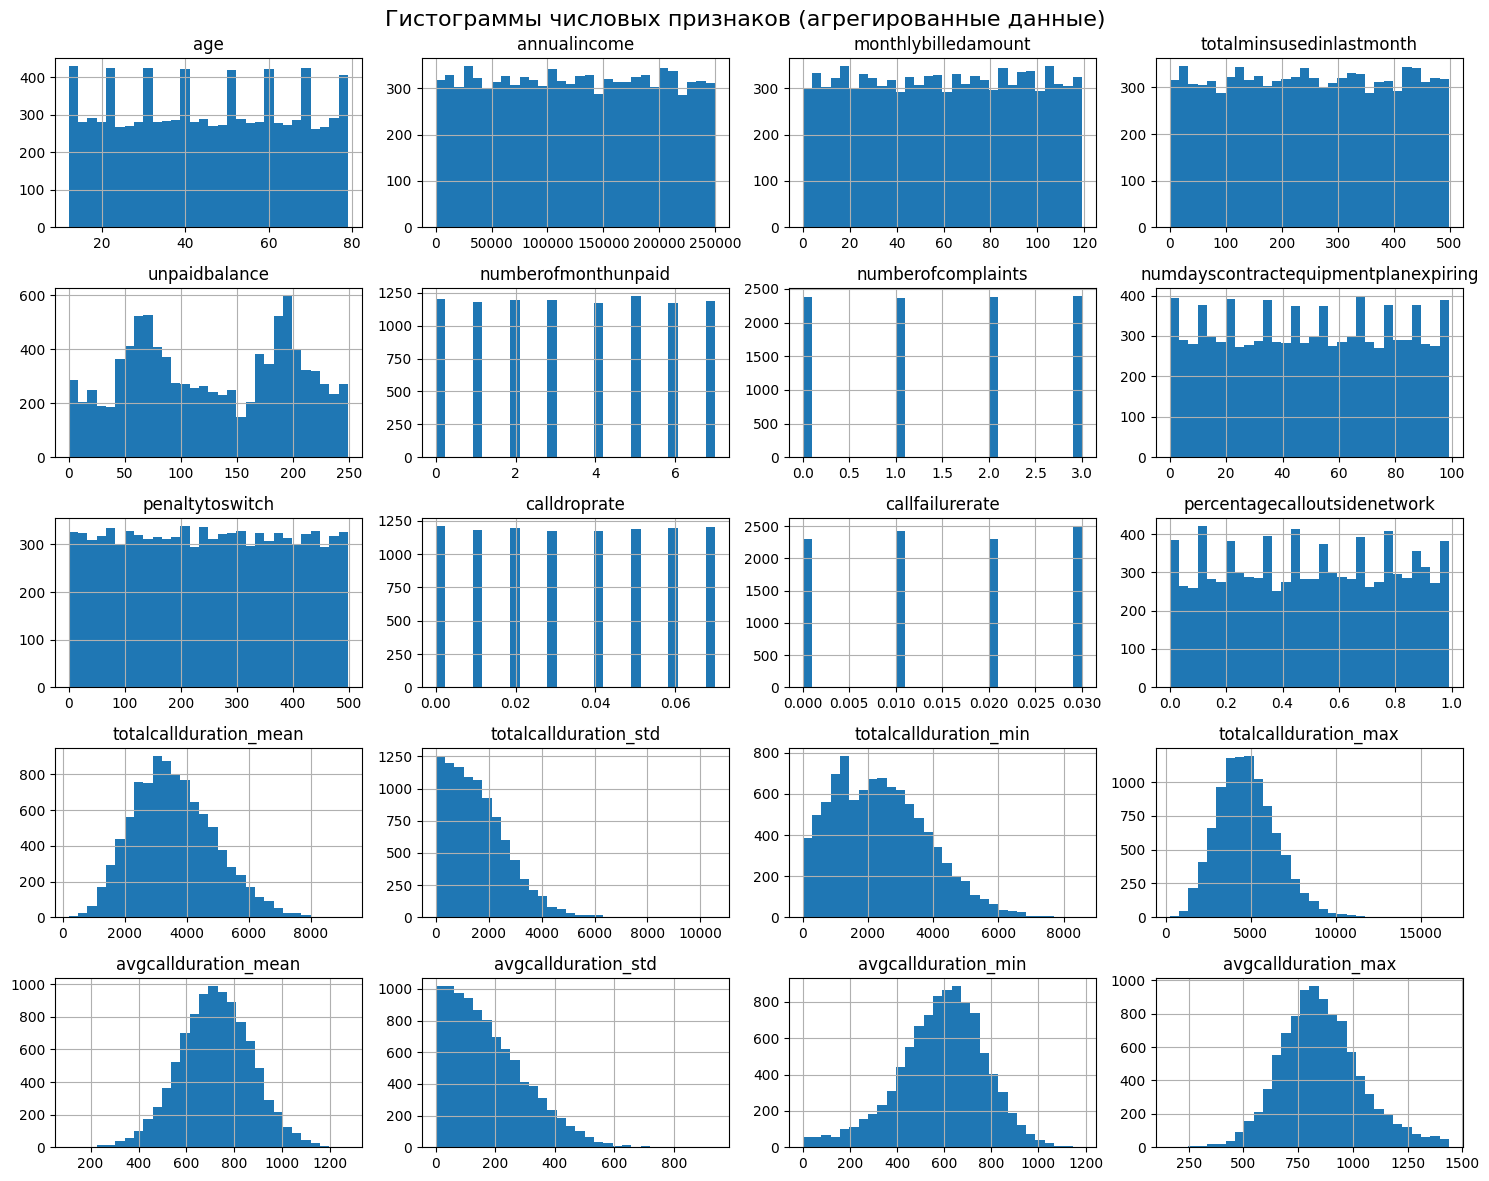

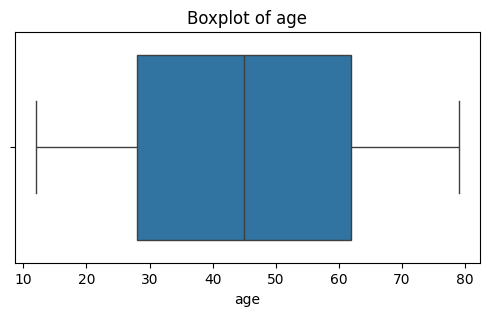

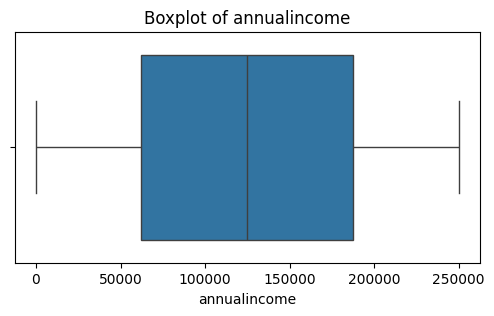

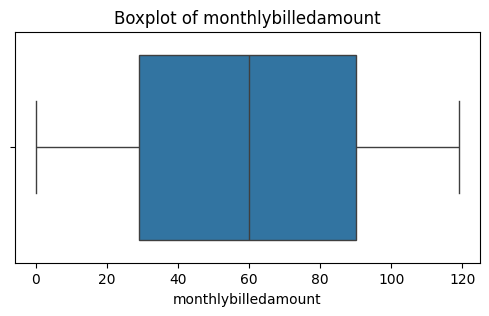

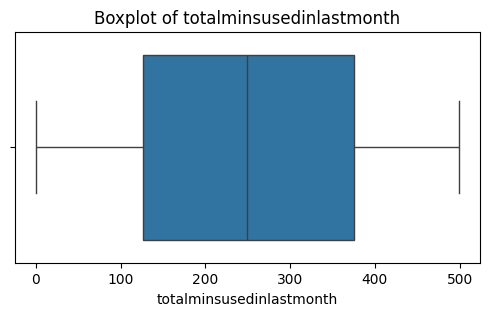

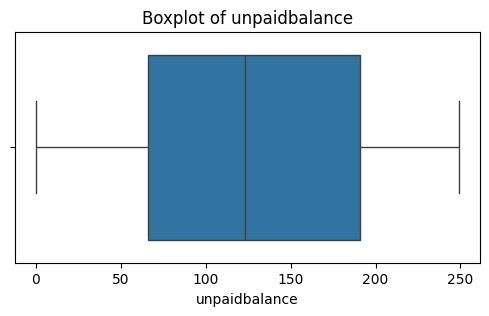

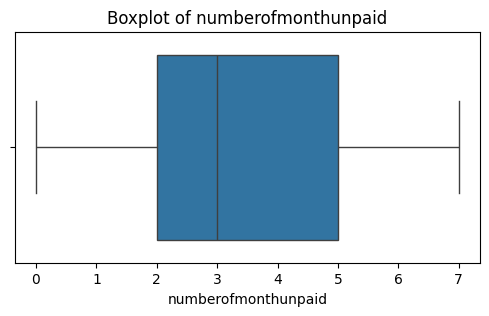

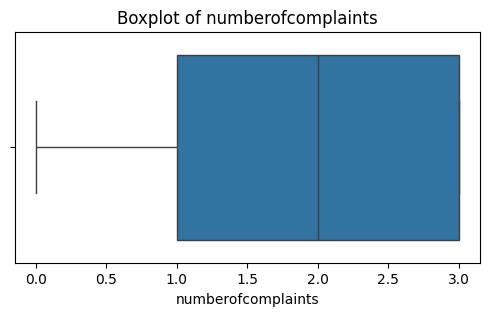

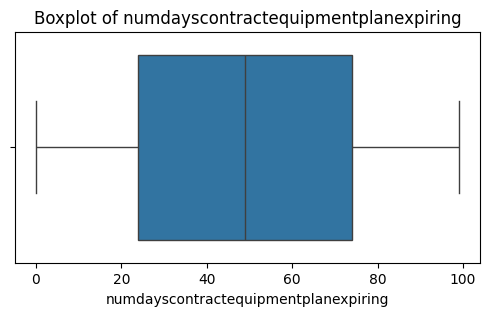

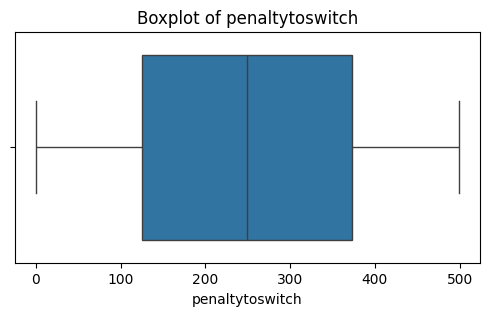

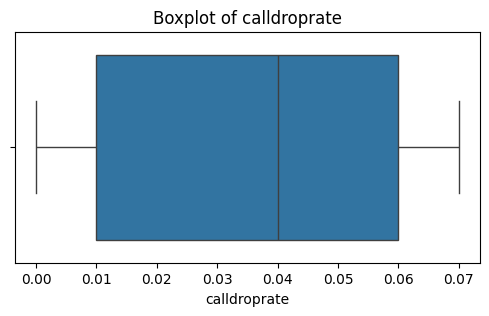

In [15]:
# Гистограммы
df_agg[num_cols].hist(bins=30, figsize=(15, 12))
plt.suptitle('Гистограммы числовых признаков (агрегированные данные)', size=16)
plt.tight_layout()
plt.show()

# Boxplots для выявления выбросов
for col in num_cols[:10]:  # ограничим для наглядности
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_agg[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

gender
Female    4880
Male      4645
Name: count, dtype: int64
--------------------------------------------------
maritalstatus
Single     4862
Married    4663
Name: count, dtype: int64
--------------------------------------------------
education
High School or below      4757
Bachelor or equivalent    2852
Master or equivalent      1440
PhD or equivalent          476
Name: count, dtype: int64
--------------------------------------------------
occupation
Others                        3809
Non-technology Related Job    2871
Technology Related Job        2845
Name: count, dtype: int64
--------------------------------------------------
homeowner
Yes    7621
No     1904
Name: count, dtype: int64
--------------------------------------------------
state
HI    225
NH    218
MD    214
AK    213
CA    212
NY    212
KY    211
MN    211
FL    211
WI    208
MT    208
WA    206
WY    206
PA    206
AZ    203
CO    203
TX    202
OH    201
SD    201
UT    200
ND    198
IN    198
DE    196
IA    195
ID

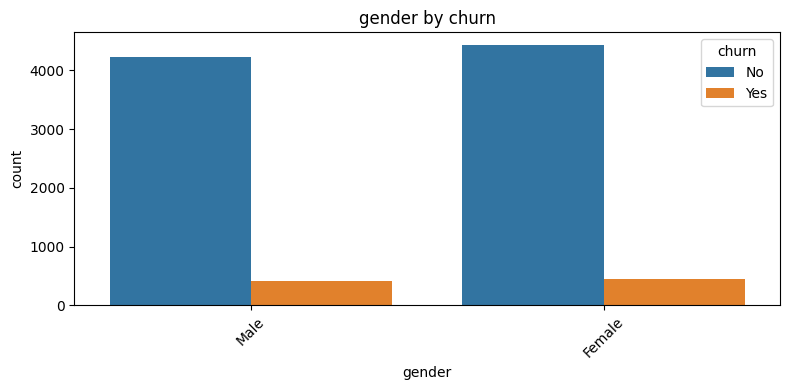

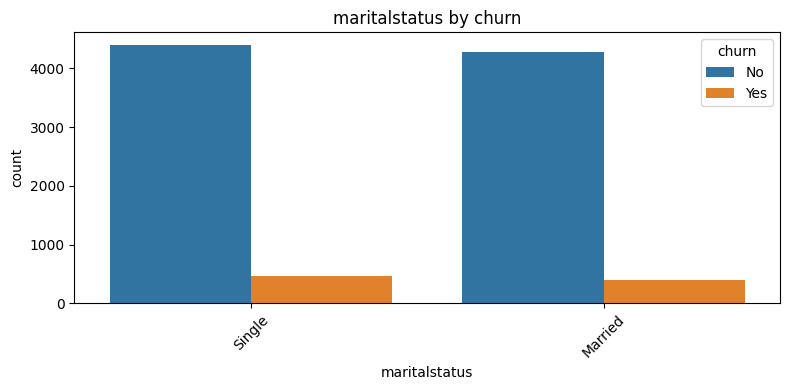

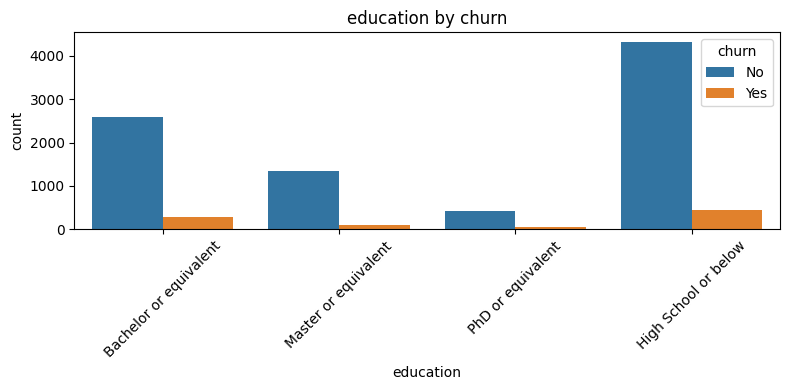

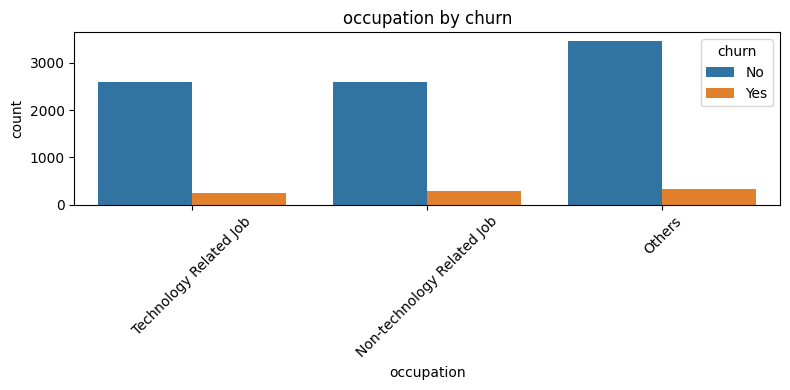

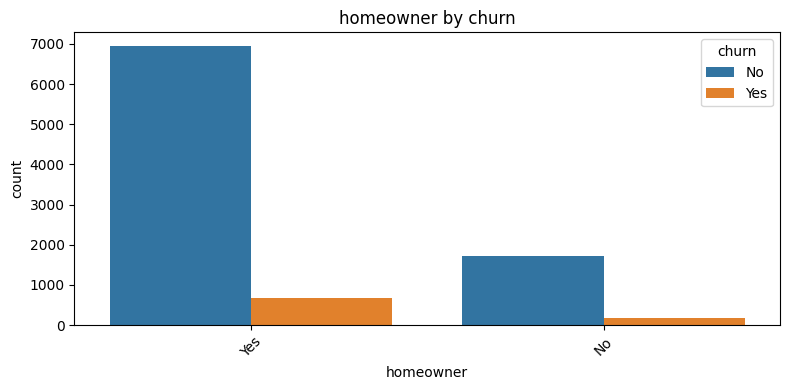

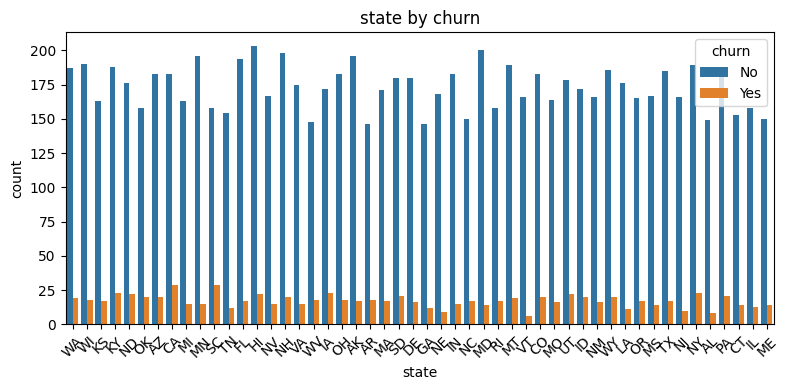

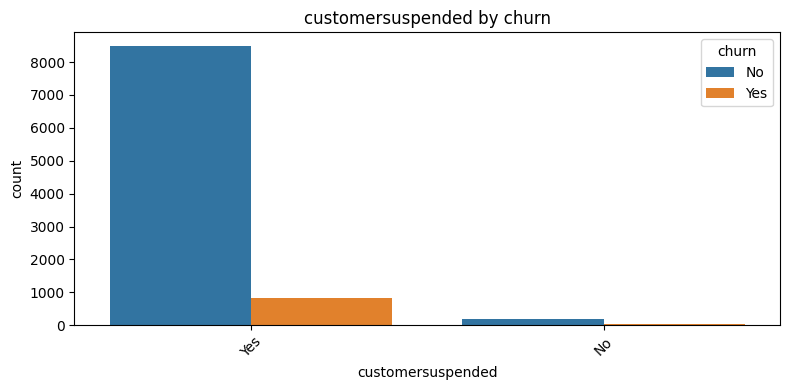

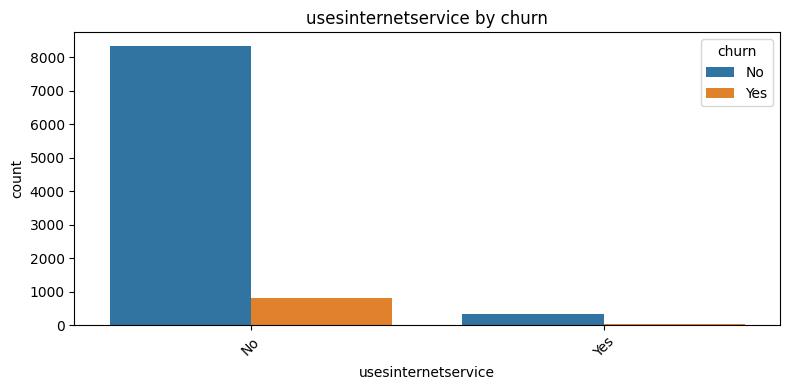

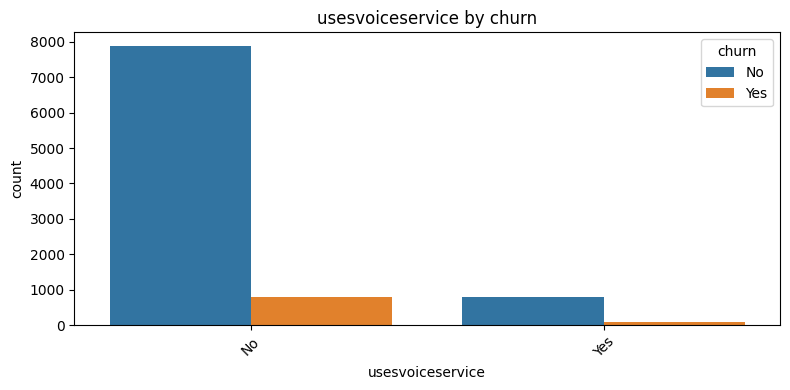

In [16]:
cat_cols = df_agg.select_dtypes(include=['str']).columns.tolist()
for col in cat_cols:
    print(df_agg[col].value_counts())
    print('-' * 50)

# Визуализация связи с churn
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df_agg, x=col, hue='churn')
    plt.title(f'{col} by churn')
    plt.xticks(rotation=45)
    plt.legend(title='churn', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

In [17]:
pd.crosstab(df_agg['customersuspended'], df_agg['churn'], normalize='index')

churn,0,1
customersuspended,,
No,0.893204,0.106796
Yes,0.909969,0.090031


In [18]:
pd.crosstab(df_agg['usesinternetservice'], df_agg['churn'], normalize='index')

churn,0,1
usesinternetservice,,
No,0.910422,0.089578
Yes,0.889488,0.110512


In [19]:
pd.crosstab(df_agg['usesvoiceservice'], df_agg['churn'], normalize='index')

churn,0,1
usesvoiceservice,,
No,0.909448,0.090552
Yes,0.911188,0.088812


Все три признака крайне несбалансированы, имеют слабую прогностическую способность и вносят шум, поэтому в процессе подготовки данных я их удалю.

churn                                   1.000000
numberofcomplaints                      0.056215
unpaidbalance                           0.045254
monthlybilledamount                     0.011172
calldroprate                            0.007033
numberofmonthunpaid                     0.006973
avgcallduration_std                     0.006672
callfailurerate                         0.005795
totalminsusedinlastmonth                0.004015
avgcallduration_max                     0.003880
penaltytoswitch                        -0.001183
avgcallduration_mean                   -0.001868
annualincome                           -0.003224
avgcallduration_min                    -0.005498
totalcallduration_min                  -0.005644
totalcallduration_std                  -0.007871
totalcallduration_max                  -0.010093
totalcallduration_mean                 -0.011134
percentagecalloutsidenetwork           -0.014797
numdayscontractequipmentplanexpiring   -0.016322
age                 

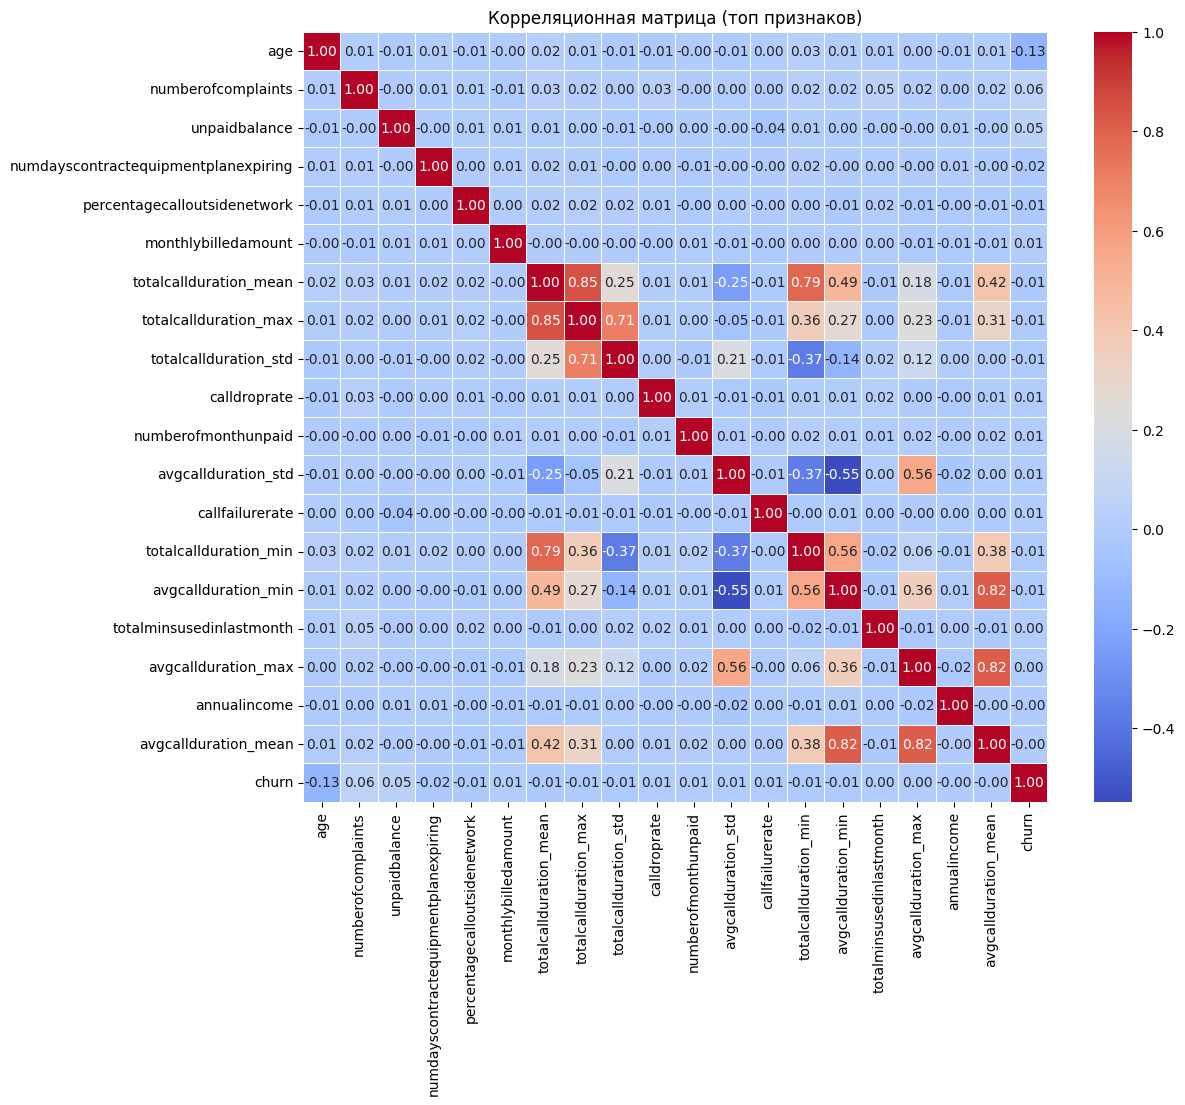

In [20]:
# Корреляция числовых признаков с churn
corr_matrix = df_agg[num_cols + ['churn']].corr()
corr_with_churn = corr_matrix['churn'].sort_values(ascending=False)
print(corr_with_churn)

# Тепловая карта корреляций между признаками (топ-20 по корреляции с churn)
top_features = corr_with_churn.abs().nlargest(20).index.tolist()
top_features = [f for f in top_features if f != 'churn']
plt.figure(figsize=(12, 10))
sns.heatmap(df_agg[top_features + ['churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица (топ признаков)')
plt.show()


numberofcomplaints:
  churn=0 mean: 1.48
  churn=1 mean: 1.70


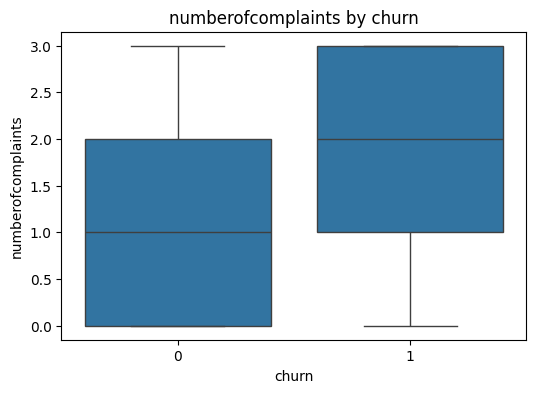


numberofmonthunpaid:
  churn=0 mean: 3.49
  churn=1 mean: 3.55


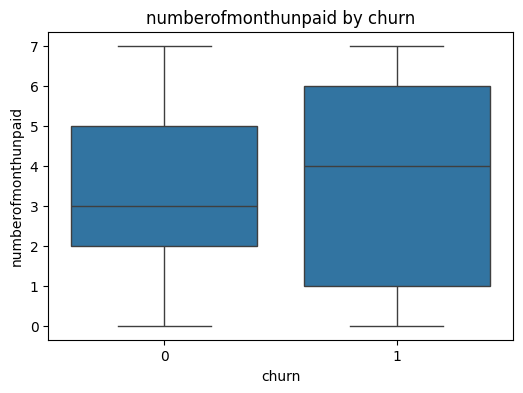


numdayscontractequipmentplanexpiring:
  churn=0 mean: 49.54
  churn=1 mean: 47.90


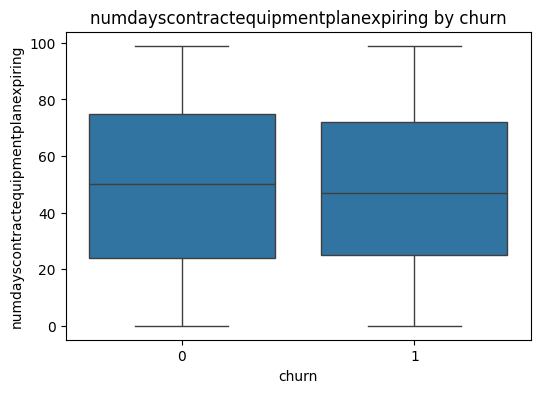


unpaidbalance:
  churn=0 mean: 125.82
  churn=1 mean: 136.92


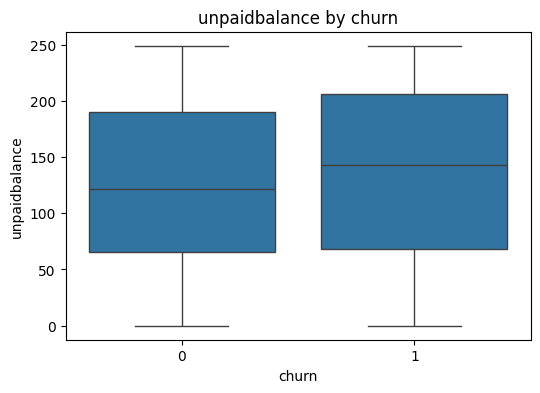


penaltytoswitch:
  churn=0 mean: 249.00
  churn=1 mean: 248.41


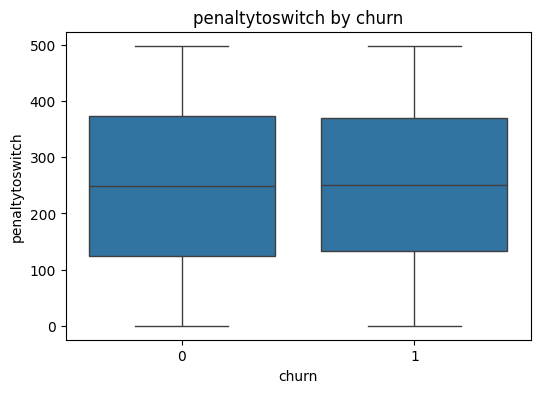


callfailurerate:
  churn=0 mean: 0.02
  churn=1 mean: 0.02


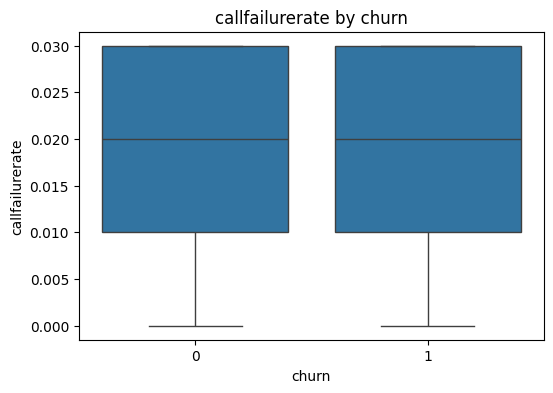


calldroprate:
  churn=0 mean: 0.03
  churn=1 mean: 0.04


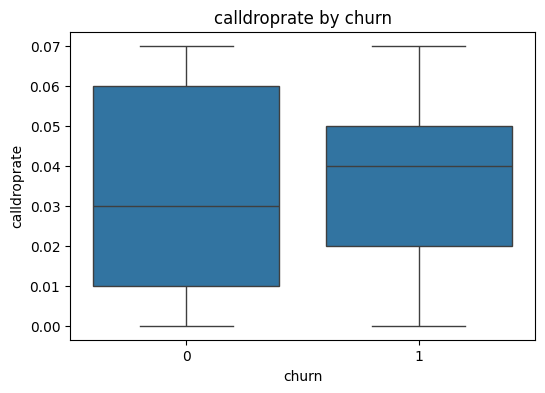


percentagecalloutsidenetwork:
  churn=0 mean: 0.50
  churn=1 mean: 0.48


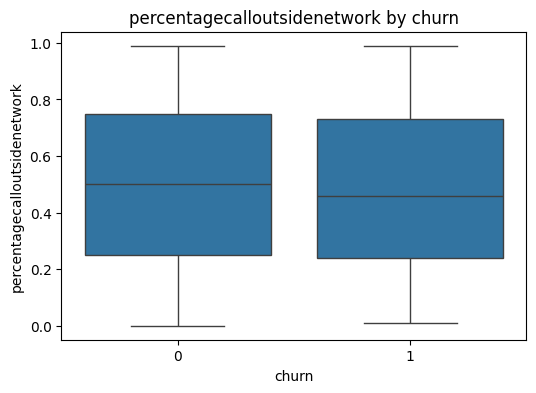


monthlybilledamount:
  churn=0 mean: 59.51
  churn=1 mean: 60.86


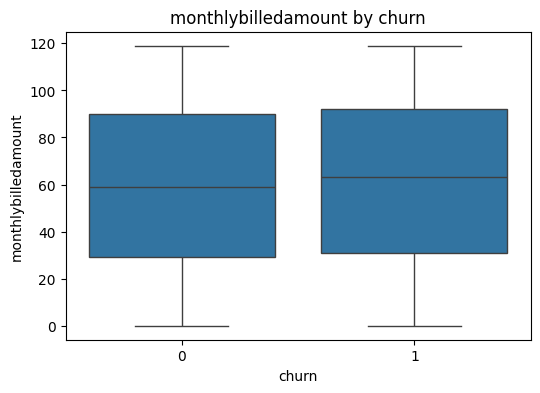

In [21]:
# Сравнение средних значений между группами churn=0 и churn=1
churn0 = df_agg[df_agg['churn'] == 0]
churn1 = df_agg[df_agg['churn'] == 1]

# Выберем ключевые признаки
key_features = ['numberofcomplaints', 'numberofmonthunpaid', 
                'numdayscontractequipmentplanexpiring', 'unpaidbalance',
                'penaltytoswitch', 'callfailurerate', 'calldroprate',
                'percentagecalloutsidenetwork', 'monthlybilledamount']

for col in key_features:
    if col in df_agg.columns:
        print(f"\n{col}:")
        print(f"  churn=0 mean: {churn0[col].mean():.2f}")
        print(f"  churn=1 mean: {churn1[col].mean():.2f}")
        plt.figure(figsize=(6,4))
        sns.boxplot(x='churn', y=col, data=df_agg)
        plt.title(f'{col} by churn')
        plt.show()

**Общий итог разведочного анализа**

Исходные данные — панельные (наблюдения по месяцам для каждого клиента). `churn` — статическая метка: если клиент когда-либо ушёл, то во всех его записях churn = 1. Для корректного моделирования проведена агрегация на уровень клиента: одна строка на customerid.

**Качество данных**

Пропущенные значения отсутствуют. Дубликатов нет, но клиенты имеют по несколько записей (в среднем ~2.5).
Явных выбросов замечено не было.

**Целевая переменная**

Доля оттока ≈ 9%. Данный дисбаланс будет учтён при обучении с помощью взвешивания классов.

**Признаки**

Удалены неинформативные категориальные признаки: `customersuspended` (2% редкого класса, разница в оттоке 1.7 п.п.), `usesinternetservice` (4% редкого класса, разница 2.1 п. п.), `usesvoiceservice` (9% редкого класса, разница 0.2 п. п.).

Корреляция с churn слабая ($\max|r| = 0.13$). Это говорит либо от отсутствии какой-либо взаимосвязи, либо о нелинейности зависимостей.

Мультиколлинеарность между агрегированными статистиками высокая, но для деревьев не критична.

Также наблюдается странное и неестественное распределение признаков. Например, возраст, годовой доход и стоимость тарифа имеют практически равномерное распределение. Хотя ожидается, что возраст будет распределён унимодально, доход — логнормально, а стоимость тарифов будет дискретной либо близкой к нормальному, но с несколькими модами. Графики boxplot также подсказывают, что признаки как будто были сгенерированы из одного распределения, но с разным масштабом. Можно увидеть, что у много признаков одинаковая форма: медиана по центру, симметричные усы, одинаковая относительная ширина ящика.

**Подход к моделированию**

Алгоритмы: использовать ансамбли деревьев (Gradient Boosting).

Балансировка: применить class_weight.

Кодирование категорий: планируется использовать Catboost, поэтому кодирование не требуется.

Валидация: из-за малого количества данных валидации не будет, но для реального проекта применял бы стратифицированую кросс-валидацию с учётом дисбаланса.

Метрики: ROC-AUC, Precision-Recall, F1-score, а также можно было бы посчитать бизнес-метрики (стоимость удержания и стоимость потери клиента, но у меня нет таких данных). Буду считать, что бизнес хочет любой ценой удержать клиентов, поэтому буду ориентироваться на максимизацию recall